# Gamification Data Pipeline — Local Simulation POC

**Luzia Streaks & Bestie Points System** — end-to-end simulation with zero infrastructure.

This notebook simulates the complete architecture locally using in-memory mocks:

| AWS Service | Local Replacement | Library |
|---|---|---|
| DynamoDB | In-memory mock | `moto` |
| Lambda | Direct function calls | Adapted code |
| Redis / ElastiCache | In-memory mock | `fakeredis` |
| S3 + Glue (PySpark) | pandas DataFrames | `pandas` |
| Redshift | SQLite in-memory | `sqlite3` (stdlib) |
| DynamoDB Streams | Manual trigger after writes | Custom simulation |

```
Real-Time Path:  App → API GW → Lambda (Ingestion) → DynamoDB → Streams → Lambda (Streak) → Redis
Batch Path:      DynamoDB Streams → Kinesis Firehose → S3 (raw) → Glue ETL → S3 (curated) → Redshift
```

**Requirements:** Python 3.11+ (for `datetime.UTC` and `ZoneInfo` stdlib support).

---
## Section 1: Setup & Architecture Overview

Initializes all mocks and shared resources that persist across cells:

- **moto `mock_aws()`** — intercepts all boto3 calls so DynamoDB operations run in-memory
- **fakeredis** — drop-in replacement for the ElastiCache Redis cluster (caching, rate limiting)
- **Dummy AWS credentials** — moto requires `AWS_ACCESS_KEY_ID` / `AWS_SECRET_ACCESS_KEY` even though nothing leaves the process
- **`decimal_to_native()`** — utility to convert DynamoDB `Decimal` types to Python `int`/`float` for pandas compatibility
- **`resources` dict** — all sections receive tables and redis via dependency injection instead of module-level globals

In [2]:
import os
import json
import random
import sqlite3
from datetime import datetime, timedelta, UTC
from decimal import Decimal
from uuid import uuid4
from zoneinfo import ZoneInfo

import boto3
import fakeredis
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from botocore.exceptions import ClientError
from moto import mock_aws

from helpers import (
    decimal_to_native, scan_table_to_df, make_event,
    ValidationError, DuplicateEventError, RateLimitError, TimezoneAbuseError,
    POINTS_MAP, VALID_EVENT_TYPES,
    validate_event, check_rate_limit, detect_timezone_abuse, process_event,
    get_previous_date, update_cache, process_streak_update,
    get_user_streak,
)

# Dummy AWS credentials — moto requires these even though nothing leaves the process
os.environ["AWS_ACCESS_KEY_ID"] = "testing"
os.environ["AWS_SECRET_ACCESS_KEY"] = "testing"
os.environ["AWS_DEFAULT_REGION"] = "us-east-1"

# Start moto mock — use .start() (not context manager) so state persists across cells
mock = mock_aws()
mock.start()

# Shared fakeredis instance — used by both event ingestion and streak processor
redis_client = fakeredis.FakeRedis(decode_responses=True)

print("Mocks started. DynamoDB, S3, and Redis are all in-memory.")

Mocks started. DynamoDB, S3, and Redis are all in-memory.


In [3]:
# ── Shared resources dict — all sections reference this instead of globals ─

resources = {
    "dynamodb": boto3.resource("dynamodb", region_name="us-east-1"),
    "redis": redis_client,
    "tables": {},  # populated in Section 2
}

---
## Section 2: DynamoDB Table Creation

Reuses logic from `code-samples/dynamodb/table_definitions.py`.

**Bug Fix #2 applied:** `StreamSpecification` added to `DailyActivity` table (required for CDC pipeline).

In [4]:
dynamodb = resources["dynamodb"]

# ── UserStreaks: hot table for current streak state and BP balance ─────────
user_streaks_table = dynamodb.create_table(
    TableName="UserStreaks",
    KeySchema=[
        {"AttributeName": "user_id", "KeyType": "HASH"},
    ],
    AttributeDefinitions=[
        {"AttributeName": "user_id", "AttributeType": "S"},
        {"AttributeName": "leaderboard_partition", "AttributeType": "S"},
        {"AttributeName": "current_streak", "AttributeType": "N"},
    ],
    GlobalSecondaryIndexes=[
        {
            "IndexName": "StreakLeaderboard",
            "KeySchema": [
                {"AttributeName": "leaderboard_partition", "KeyType": "HASH"},
                {"AttributeName": "current_streak", "KeyType": "RANGE"},
            ],
            "Projection": {
                "ProjectionType": "INCLUDE",
                "NonKeyAttributes": ["user_id", "longest_streak", "total_bestie_points"],
            },
        },
    ],
    BillingMode="PAY_PER_REQUEST",
)
user_streaks_table.wait_until_exists()
print("Created: UserStreaks")

# ── BPEvents: append-only event log with IdempotencyIndex GSI ─────────────
bp_events_table = dynamodb.create_table(
    TableName="BPEvents",
    KeySchema=[
        {"AttributeName": "user_id", "KeyType": "HASH"},
        {"AttributeName": "event_id", "KeyType": "RANGE"},
    ],
    AttributeDefinitions=[
        {"AttributeName": "user_id", "AttributeType": "S"},
        {"AttributeName": "event_id", "AttributeType": "S"},
        {"AttributeName": "idempotency_key", "AttributeType": "S"},
    ],
    GlobalSecondaryIndexes=[
        {
            "IndexName": "IdempotencyIndex",
            "KeySchema": [
                {"AttributeName": "idempotency_key", "KeyType": "HASH"},
            ],
            "Projection": {"ProjectionType": "KEYS_ONLY"},
        },
    ],
    BillingMode="PAY_PER_REQUEST",
)
bp_events_table.wait_until_exists()
# Enable TTL for automatic event expiration (90 days)
dynamodb.meta.client.update_time_to_live(
    TableName="BPEvents",
    TimeToLiveSpecification={"Enabled": True, "AttributeName": "ttl"},
)
print("Created: BPEvents (with IdempotencyIndex GSI + TTL)")

# ── DailyActivity: one record per user per day (with Streams for CDC) ─────
daily_activity_table = dynamodb.create_table(
    TableName="DailyActivity",
    KeySchema=[
        {"AttributeName": "user_id", "KeyType": "HASH"},
        {"AttributeName": "activity_date", "KeyType": "RANGE"},
    ],
    AttributeDefinitions=[
        {"AttributeName": "user_id", "AttributeType": "S"},
        {"AttributeName": "activity_date", "AttributeType": "S"},
    ],
    BillingMode="PAY_PER_REQUEST",
    StreamSpecification={
        "StreamEnabled": True,
        "StreamViewType": "NEW_IMAGE",
    },
)
daily_activity_table.wait_until_exists()
print("Created: DailyActivity (with DynamoDB Streams enabled)")

# Store table references in shared resources
resources["tables"] = {
    "UserStreaks": user_streaks_table,
    "BPEvents": bp_events_table,
    "DailyActivity": daily_activity_table,
}

Created: UserStreaks
Created: BPEvents (with IdempotencyIndex GSI + TTL)
Created: DailyActivity (with DynamoDB Streams enabled)


In [5]:
# ── Verify table schemas ──────────────────────────────────────────────────

table_info = []
for name in ["UserStreaks", "BPEvents", "DailyActivity"]:
    desc = dynamodb.meta.client.describe_table(TableName=name)["Table"]
    keys = ", ".join(f"{k['AttributeName']} ({k['KeyType']})" for k in desc["KeySchema"])
    gsis = ", ".join(g["IndexName"] for g in desc.get("GlobalSecondaryIndexes", []))
    stream = desc.get("StreamSpecification", {}).get("StreamViewType", "—")
    table_info.append({"Table": name, "Keys": keys, "GSIs": gsis or "—", "Stream": stream})

pd.DataFrame(table_info)

,Table,Keys,GSIs,Stream
0,UserStreaks,user_id (HASH),StreakLeaderboard,—
1,BPEvents,"user_id (HASH), event_id (RANGE)",IdempotencyIndex,—
2,DailyActivity,"user_id (HASH), activity_date (RANGE)",—,NEW_IMAGE


---
## Section 3: Sample Data Generation

6 users, each testing a different scenario. All timestamps are generated **relative to `now()`** to stay within the `validate_event()` acceptance window (≤7 days past, ≤24h future).

| User | Timezone | Scenario |
|---|---|---|
| `usr_alice` | `America/Sao_Paulo` | 7-day streak, 1-day gap, 3-day restart |
| `usr_bob` | `Asia/Tokyo` | Near-midnight activity (23:58 / 00:02 local) |
| `usr_carol` | `Europe/London` | DST transition test |
| `usr_dave` | `America/New_York` | Sends duplicate events (same idempotency key) |
| `usr_eve` | `Pacific/Auckland` | Extreme UTC+13 offset, date boundary |
| `usr_frank` | `America/Sao_Paulo` | >100 events/hour (rate-limit) + bad payloads |

In [6]:
# ── Data generation ───────────────────────────────────────────────────────

rng = random.Random(42)  # Seeded for reproducible idempotency keys

EVENT_TYPES = ["CONVERSATION_START", "TOOL_USE", "DAILY_OPEN", "SHARE_RESULT"]
SOURCES = ["mobile_app", "web", "whatsapp"]

# Base time: now at noon UTC — all events are offsets from this
T = datetime.now(UTC).replace(hour=12, minute=0, second=0, microsecond=0)

events = []

# ── Alice: T-6,T-5,T-4,T-3 = 4-day streak → gap at T-2 → T-1,T-0 = 2-day restart
alice_tz = "America/Sao_Paulo"
alice_active_days = [6, 5, 4, 3, 1, 0]  # skip day T-2
for day_offset in alice_active_days:
    ts = T - timedelta(days=day_offset, hours=rng.randint(0, 8))
    events.append(make_event("usr_alice", rng.choice(EVENT_TYPES), ts, alice_tz, rng=rng))
    if day_offset in [6, 4, 0]:
        ts2 = ts + timedelta(hours=rng.randint(1, 4))
        events.append(make_event("usr_alice", rng.choice(EVENT_TYPES), ts2, alice_tz, rng=rng))

# ── Bob: Near-midnight activity — 23:58 and 00:02 local time on consecutive days
bob_tz = "Asia/Tokyo"  # UTC+9
for day_offset in [3, 2, 1, 0]:
    tz_obj = ZoneInfo(bob_tz)
    base_day = (T - timedelta(days=day_offset)).astimezone(tz_obj)
    late_ts = base_day.replace(hour=23, minute=58, second=0).astimezone(ZoneInfo("UTC"))
    events.append(make_event("usr_bob", rng.choice(EVENT_TYPES), late_ts, bob_tz, rng=rng))
    if day_offset in [2, 0]:
        early_ts = base_day.replace(hour=0, minute=2, second=0).astimezone(ZoneInfo("UTC"))
        events.append(make_event("usr_bob", rng.choice(EVENT_TYPES), early_ts, bob_tz, rng=rng))

# ── Carol: DST transition test — events on consecutive days across TZ boundary
carol_tz = "Europe/London"
for day_offset in [3, 2, 1, 0]:
    ts = T - timedelta(days=day_offset, hours=rng.randint(2, 10))
    events.append(make_event("usr_carol", rng.choice(EVENT_TYPES), ts, carol_tz, rng=rng))

# ── Dave: Duplicate events — same idempotency key repeated 5 times
dave_tz = "America/New_York"
dave_total_sent = 0
for day_offset in [2, 1, 0]:
    ts = T - timedelta(days=day_offset, hours=rng.randint(2, 8))
    events.append(make_event("usr_dave", "CONVERSATION_START", ts, dave_tz, rng=rng))
    dave_total_sent += 1
    dup_key = events[-1]["idempotency_key"]
    for _ in range(4):
        events.append(make_event("usr_dave", "CONVERSATION_START", ts, dave_tz, idemp_key=dup_key, rng=rng))
        dave_total_sent += 1

# ── Eve: Extreme UTC+13 offset (New Zealand) — date boundary crossing
eve_tz = "Pacific/Auckland"
for day_offset in [3, 2, 1, 0]:
    tz_obj = ZoneInfo(eve_tz)
    base_day = (T - timedelta(days=day_offset)).astimezone(tz_obj)
    ts = base_day.replace(hour=23, minute=15, second=0).astimezone(ZoneInfo("UTC"))
    events.append(make_event("usr_eve", rng.choice(EVENT_TYPES), ts, eve_tz, rng=rng))

# ── Frank: 105 events in 1 hour (rate-limit) + 5 bad payloads
frank_tz = "America/Sao_Paulo"
frank_base = T - timedelta(hours=2)
for i in range(105):
    ts = frank_base + timedelta(seconds=i * 30)
    events.append(make_event("usr_frank", rng.choice(EVENT_TYPES), ts, frank_tz, rng=rng))

for i in range(5):
    ts = frank_base + timedelta(minutes=55 + i)
    events.append(make_event("usr_frank", "INVALID_TYPE", ts, frank_tz, rng=rng))

print(f"Total events generated: {len(events)}")
print(f"Dave's total events sent (including duplicates): {dave_total_sent}")

events_df = pd.DataFrame(events)
print(f"\nEvents per user:")
display(events_df.groupby("user_id").agg(
    count=("event_type", "count"),
    event_types=("event_type", "nunique"),
    sources=("source", "nunique"),
))
print(f"\nSample events:")
display(events_df.head(10))

Total events generated: 148
Dave's total events sent (including duplicates): 15

Events per user:


,count,event_types,sources
user_id,,,
usr_alice,9,4,2
usr_bob,6,4,3
usr_carol,4,2,2
usr_dave,15,1,3
usr_eve,4,2,3
usr_frank,110,5,3



Sample events:


,user_id,event_type,client_timestamp,timezone,idempotency_key,source
0,usr_alice,CONVERSATION_START,2026-02-28T08:00:00-03:00,America/Sao_Paulo,usr_alice:CONVERSATION_START:2026-02-28T08:00:...,whatsapp
1,usr_alice,TOOL_USE,2026-02-28T11:00:00-03:00,America/Sao_Paulo,usr_alice:TOOL_USE:2026-02-28T11:00:00-03:00,mobile_app
2,usr_alice,CONVERSATION_START,2026-03-01T07:00:00-03:00,America/Sao_Paulo,usr_alice:CONVERSATION_START:2026-03-01T07:00:...,whatsapp
3,usr_alice,CONVERSATION_START,2026-03-02T01:00:00-03:00,America/Sao_Paulo,usr_alice:CONVERSATION_START:2026-03-02T01:00:...,whatsapp
4,usr_alice,CONVERSATION_START,2026-03-02T05:00:00-03:00,America/Sao_Paulo,usr_alice:CONVERSATION_START:2026-03-02T05:00:...,mobile_app
5,usr_alice,TOOL_USE,2026-03-03T08:00:00-03:00,America/Sao_Paulo,usr_alice:TOOL_USE:2026-03-03T08:00:00-03:00,mobile_app
6,usr_alice,CONVERSATION_START,2026-03-05T01:00:00-03:00,America/Sao_Paulo,usr_alice:CONVERSATION_START:2026-03-05T01:00:...,whatsapp
7,usr_alice,SHARE_RESULT,2026-03-06T06:00:00-03:00,America/Sao_Paulo,usr_alice:SHARE_RESULT:2026-03-06T06:00:00-03:00,mobile_app
8,usr_alice,DAILY_OPEN,2026-03-06T10:00:00-03:00,America/Sao_Paulo,usr_alice:DAILY_OPEN:2026-03-06T10:00:00-03:00,mobile_app
9,usr_bob,TOOL_USE,2026-03-03T23:58:00+09:00,Asia/Tokyo,usr_bob:TOOL_USE:2026-03-03T23:58:00+09:00,whatsapp


---
## Section 4: Real-Time Path — Event Ingestion

Adapted from `code-samples/lambda/event_ingestion.py` with dependency injection (no module-level globals).

**Bug fixes applied:**
- **#1 (Critical):** Added GSI lookup on `IdempotencyIndex` before write — the original `attribute_not_exists` conditional write doesn't actually deduplicate because `event_id` contains a UUID.
- **#4:** Integrated `check_rate_limit()` and `detect_timezone_abuse()` into `process_event()`.
- **#4a:** Maintaining `recent_tz_changes` on UserStreaks when timezone changes.

In [7]:
# Exception classes, validation, anomaly detection, and process_event
# are all imported from helpers.py — see the import cell above.

In [8]:
# ── Process all events with progress tracking ─────────────────────────────

bp_tbl = resources["tables"]["BPEvents"]
daily_tbl = resources["tables"]["DailyActivity"]
streaks_tbl = resources["tables"]["UserStreaks"]
redis_conn = resources["redis"]

results = {"processed": 0, "duplicate": 0, "rate_limited": 0, "validation_error": 0, "error": 0}
ingestion_log = []  # Detailed log for display

for i, event in enumerate(events):
    try:
        validated = validate_event(event)
        result = process_event(validated, bp_tbl, daily_tbl, streaks_tbl, redis_conn)
        results["processed"] += 1
        ingestion_log.append({"user_id": event["user_id"], "status": "processed", "detail": result["event_id"]})
    except ValidationError as e:
        results["validation_error"] += 1
        ingestion_log.append({"user_id": event["user_id"], "status": "validation_error", "detail": str(e)})
    except DuplicateEventError:
        results["duplicate"] += 1
        ingestion_log.append({"user_id": event["user_id"], "status": "duplicate", "detail": event["idempotency_key"]})
    except RateLimitError:
        results["rate_limited"] += 1
        ingestion_log.append({"user_id": event["user_id"], "status": "rate_limited", "detail": ""})
    except TimezoneAbuseError:
        results["error"] += 1
        ingestion_log.append({"user_id": event["user_id"], "status": "tz_abuse", "detail": ""})
    except Exception as e:
        results["error"] += 1
        ingestion_log.append({"user_id": event["user_id"], "status": "error", "detail": str(e)})

print("=" * 60)
print("INGESTION RESULTS")
print("=" * 60)
for k, v in results.items():
    print(f"  {k:>20}: {v}")
print(f"  {'total':>20}: {sum(results.values())}")

# Per-user breakdown
log_df = pd.DataFrame(ingestion_log)
print("\nPer-user status breakdown:")
display(log_df.groupby(["user_id", "status"]).size().unstack(fill_value=0))

INGESTION RESULTS
             processed: 126
             duplicate: 12
          rate_limited: 5
      validation_error: 5
                 error: 0
                 total: 148

Per-user status breakdown:


status,duplicate,processed,rate_limited,validation_error
user_id,,,,
usr_alice,0,9,0,0
usr_bob,0,6,0,0
usr_carol,0,4,0,0
usr_dave,12,3,0,0
usr_eve,0,4,0,0
usr_frank,0,100,5,5


In [35]:
# ── Display DynamoDB table states ─────────────────────────────────────────

print("BPEvents table:")
bp_events_df = scan_table_to_df(bp_tbl)
display(bp_events_df[["user_id", "event_id", "event_type", "points_awarded", "idempotency_key", "source"]].head(15))

print(f"\nDailyActivity table:")
daily_df = scan_table_to_df(daily_tbl)
display(daily_df.sort_values(["user_id", "activity_date"]))

print(f"\nUserStreaks table (streaks not yet computed — only BP and timezone):")
streaks_pre_df = scan_table_to_df(streaks_tbl)
display(streaks_pre_df)

BPEvents table:


,user_id,event_id,event_type,points_awarded,idempotency_key,source
0,usr_alice,20260228T110000#08c289bb,CONVERSATION_START,10,usr_alice:CONVERSATION_START:2026-02-28T08:00:...,whatsapp
1,usr_alice,20260228T140000#8322ba74,TOOL_USE,5,usr_alice:TOOL_USE:2026-02-28T11:00:00-03:00,mobile_app
2,usr_alice,20260301T100000#a7c95d52,CONVERSATION_START,10,usr_alice:CONVERSATION_START:2026-03-01T07:00:...,whatsapp
3,usr_alice,20260302T040000#df461069,CONVERSATION_START,10,usr_alice:CONVERSATION_START:2026-03-02T01:00:...,whatsapp
4,usr_alice,20260302T080000#08111210,CONVERSATION_START,10,usr_alice:CONVERSATION_START:2026-03-02T05:00:...,mobile_app
5,usr_alice,20260303T110000#27393127,TOOL_USE,5,usr_alice:TOOL_USE:2026-03-03T08:00:00-03:00,mobile_app
6,usr_alice,20260305T040000#ce35c064,CONVERSATION_START,10,usr_alice:CONVERSATION_START:2026-03-05T01:00:...,whatsapp
7,usr_alice,20260306T090000#16a21106,SHARE_RESULT,15,usr_alice:SHARE_RESULT:2026-03-06T06:00:00-03:00,mobile_app
8,usr_alice,20260306T130000#e0f863d9,DAILY_OPEN,1,usr_alice:DAILY_OPEN:2026-03-06T10:00:00-03:00,mobile_app
9,usr_bob,20260303T145800#b5ac3c89,TOOL_USE,5,usr_bob:TOOL_USE:2026-03-03T23:58:00+09:00,whatsapp



DailyActivity table:


,user_id,activity_date,first_event_id,created_at,events_count,points_earned
0,usr_alice,2026-02-28,20260228T110000#08c289bb,2026-02-28T11:00:00+00:00,2,15
1,usr_alice,2026-03-01,20260301T100000#a7c95d52,2026-03-01T10:00:00+00:00,1,10
2,usr_alice,2026-03-02,20260302T040000#df461069,2026-03-02T04:00:00+00:00,2,20
3,usr_alice,2026-03-03,20260303T110000#27393127,2026-03-03T11:00:00+00:00,1,5
4,usr_alice,2026-03-05,20260305T040000#ce35c064,2026-03-05T04:00:00+00:00,1,10
5,usr_alice,2026-03-06,20260306T090000#16a21106,2026-03-06T09:00:00+00:00,2,16
6,usr_bob,2026-03-03,20260303T145800#b5ac3c89,2026-03-03T14:58:00+00:00,1,5
7,usr_bob,2026-03-04,20260304T145800#4e39d7f3,2026-03-04T14:58:00+00:00,2,16
8,usr_bob,2026-03-05,20260305T145800#31771781,2026-03-05T14:58:00+00:00,1,5
9,usr_bob,2026-03-06,20260306T145800#c0eb17ed,2026-03-06T14:58:00+00:00,2,25



UserStreaks table (streaks not yet computed — only BP and timezone):


,user_id,total_bestie_points,timezone,streak_updated_at,current_streak,longest_streak,last_activity_date,version
0,usr_alice,76,America/Sao_Paulo,2026-03-06T15:10:15.361979+00:00,2,4,2026-03-06,6
1,usr_bob,51,Asia/Tokyo,2026-03-06T15:10:15.371709+00:00,4,4,2026-03-06,4
2,usr_carol,22,Europe/London,2026-03-06T15:10:15.381264+00:00,4,4,2026-03-06,4
3,usr_dave,30,America/New_York,2026-03-06T15:10:15.386436+00:00,2,2,2026-03-05,2
4,usr_eve,8,Pacific/Auckland,2026-03-06T15:10:15.396910+00:00,4,4,2026-03-07,4
5,usr_frank,783,America/Sao_Paulo,2026-03-06T15:10:15.399383+00:00,1,1,2026-03-06,1


In [10]:
# ── Assertions: Section 4 ─────────────────────────────────────────────────

# Dave's duplicates caught — he sent 15 events (3 unique * 5 copies) but only 3 should be stored
dave_bp_events = bp_events_df[bp_events_df["user_id"] == "usr_dave"]
assert len(dave_bp_events) < dave_total_sent, \
    f"Dedup failed: Dave has {len(dave_bp_events)} stored events but sent {dave_total_sent}"
assert len(dave_bp_events) == 3, \
    f"Dave should have exactly 3 unique events, got {len(dave_bp_events)}"
print(f"PASS: Dave sent {dave_total_sent} events, only {len(dave_bp_events)} stored (dedup works)")

# Frank's rate limiting
assert results["rate_limited"] > 0, "Frank's burst should trigger rate limiting"
print(f"PASS: {results['rate_limited']} events were rate-limited")

# Frank's bad payloads
assert results["validation_error"] >= 5, \
    f"Expected ≥5 validation errors for Frank's bad payloads, got {results['validation_error']}"
print(f"PASS: {results['validation_error']} validation errors caught")

print("\nAll Section 4 assertions passed.")

PASS: Dave sent 15 events, only 3 stored (dedup works)
PASS: 5 events were rate-limited
PASS: 5 validation errors caught

All Section 4 assertions passed.


---
## Section 5: Real-Time Path — Streak Processor

Adapted from `code-samples/lambda/streak_processor.py` with dependency injection.

**Bug Fix #3 applied:** `get_previous_date` now uses timezone-aware datetime arithmetic (anchored at noon) instead of naive string-based math. This handles DST transitions correctly.

**Stream simulation:** Since moto doesn't emit real DynamoDB Stream events, we scan `DailyActivity`, sort by `(user_id, activity_date)`, and call the streak processor for each record chronologically.

In [11]:
# Streak processor functions (get_previous_date, update_cache, process_streak_update)
# are all imported from helpers.py — see the import cell above.

In [12]:
# ── Simulate DynamoDB Streams: scan DailyActivity and process chronologically

daily_items = daily_tbl.scan()["Items"]
# Sort by user_id then activity_date to process in chronological order per user
daily_items.sort(key=lambda x: (x["user_id"], x["activity_date"]))

print("Processing streak updates (simulating DynamoDB Streams)...\n")
for item in daily_items:
    process_streak_update(
        user_id=item["user_id"],
        activity_date=item["activity_date"],
        streaks_tbl=streaks_tbl,
        redis_conn=redis_conn,
    )

print("\nStreak processing complete.")

Processing streak updates (simulating DynamoDB Streams)...

  usr_alice: streak 0 -> 1 (date: 2026-02-28)
  usr_alice: streak 1 -> 2 (date: 2026-03-01)
  usr_alice: streak 2 -> 3 (date: 2026-03-02)
  usr_alice: streak 3 -> 4 (date: 2026-03-03)
  usr_alice: streak 4 -> 1 (date: 2026-03-05)
  usr_alice: streak 1 -> 2 (date: 2026-03-06)
  usr_bob: streak 0 -> 1 (date: 2026-03-03)
  usr_bob: streak 1 -> 2 (date: 2026-03-04)
  usr_bob: streak 2 -> 3 (date: 2026-03-05)
  usr_bob: streak 3 -> 4 (date: 2026-03-06)
  usr_carol: streak 0 -> 1 (date: 2026-03-03)
  usr_carol: streak 1 -> 2 (date: 2026-03-04)
  usr_carol: streak 2 -> 3 (date: 2026-03-05)
  usr_carol: streak 3 -> 4 (date: 2026-03-06)
  usr_dave: streak 0 -> 1 (date: 2026-03-04)
  usr_dave: streak 1 -> 2 (date: 2026-03-05)
  usr_eve: streak 0 -> 1 (date: 2026-03-04)
  usr_eve: streak 1 -> 2 (date: 2026-03-05)
  usr_eve: streak 2 -> 3 (date: 2026-03-06)
  usr_eve: streak 3 -> 4 (date: 2026-03-07)
  usr_frank: streak 0 -> 1 (date: 2026

In [13]:
# ── Display: UserStreaks table (now with streak data) ──────────────────────

print("UserStreaks table (with streaks computed):")
streaks_df = scan_table_to_df(streaks_tbl)
display_cols = ["user_id", "current_streak", "longest_streak", "last_activity_date",
                "total_bestie_points", "timezone", "version"]
existing_cols = [c for c in display_cols if c in streaks_df.columns]
display(streaks_df[existing_cols].sort_values("user_id"))

# Display Redis cache state
print("\nRedis cache state (streak:* keys):")
cache_data = []
for user_id in sorted(streaks_df["user_id"].unique()):
    cached = redis_conn.get(f"streak:{user_id}")
    if cached:
        cache_data.append({"user_id": user_id, **json.loads(cached)})
if cache_data:
    display(pd.DataFrame(cache_data))
else:
    print("  (no cache entries)")

UserStreaks table (with streaks computed):


,user_id,current_streak,longest_streak,last_activity_date,total_bestie_points,timezone,version
0,usr_alice,2,4,2026-03-06,76,America/Sao_Paulo,6
1,usr_bob,4,4,2026-03-06,51,Asia/Tokyo,4
2,usr_carol,4,4,2026-03-06,22,Europe/London,4
3,usr_dave,2,2,2026-03-05,30,America/New_York,2
4,usr_eve,4,4,2026-03-07,8,Pacific/Auckland,4
5,usr_frank,1,1,2026-03-06,783,America/Sao_Paulo,1



Redis cache state (streak:* keys):


,user_id,current_streak,longest_streak,total_bestie_points
0,usr_alice,2,4,76
1,usr_bob,4,4,51
2,usr_carol,4,4,22
3,usr_dave,2,2,30
4,usr_eve,4,4,8
5,usr_frank,1,1,783


In [14]:
# ── Assertions: Section 5 ─────────────────────────────────────────────────

# Alice: activity on T-6,T-5,T-4,T-3 (streak=4), skip T-2, T-1,T-0 (streak=2)
alice = streaks_df[streaks_df["user_id"] == "usr_alice"].iloc[0]
assert alice["longest_streak"] == 4, \
    f"Alice longest should be 4, got {alice['longest_streak']}"
assert alice["current_streak"] == 2, \
    f"Alice current should be 2, got {alice['current_streak']}"
print(f"PASS: Alice — longest_streak={alice['longest_streak']}, current_streak={alice['current_streak']}")

# Bob: near-midnight events on 4 consecutive days → should have streak of 4
bob = streaks_df[streaks_df["user_id"] == "usr_bob"].iloc[0]
assert bob["current_streak"] >= 2, \
    f"Bob's near-midnight events should count as consecutive days, got streak={bob['current_streak']}"
print(f"PASS: Bob — current_streak={bob['current_streak']} (near-midnight events are consecutive)")

# Carol: 4 consecutive days → streak of 4
carol = streaks_df[streaks_df["user_id"] == "usr_carol"].iloc[0]
assert carol["current_streak"] >= 2, \
    f"Carol's DST-boundary streak should work, got {carol['current_streak']}"
print(f"PASS: Carol — current_streak={carol['current_streak']} (DST transition handled)")

# Eve: 4 consecutive days at UTC+13 → streak should be correct
eve = streaks_df[streaks_df["user_id"] == "usr_eve"].iloc[0]
assert eve["current_streak"] >= 2, \
    f"Eve's UTC+13 offset should produce consecutive days, got {eve['current_streak']}"
print(f"PASS: Eve — current_streak={eve['current_streak']} (UTC+13 offset handled)")

print("\nAll Section 5 assertions passed.")

PASS: Alice — longest_streak=4, current_streak=2
PASS: Bob — current_streak=4 (near-midnight events are consecutive)
PASS: Carol — current_streak=4 (DST transition handled)
PASS: Eve — current_streak=4 (UTC+13 offset handled)

All Section 5 assertions passed.


---
## Section 6: Cache Layer Verification

Validates the **write-through caching** strategy:

1. **Read path**: Every read checks Redis first (`streak:{user_id}`). On cache miss, falls back to DynamoDB and populates the cache.
2. **Forced cache miss**: Deletes one user's cache key, then reads — should fetch from DynamoDB and re-populate Redis.
3. **Consistency check**: Compares `current_streak` in Redis vs DynamoDB for all users — must match exactly (write-through guarantee).
4. **BP reconciliation**: Sums `points_awarded` from `BPEvents` and compares against `total_bestie_points` in `UserStreaks`. Any mismatch indicates a bug in the atomic increment logic.
5. **Rate-limit inspection**: Shows Redis `rate:{user_id}` keys to confirm the token-bucket counters are working.

In [15]:
# get_user_streak is imported from helpers.py

# Test read path for all users
user_ids = sorted(streaks_df["user_id"].unique())
print("Read path results (all should be CACHE_HIT since streak processor just ran):")
read_results = []
for uid in user_ids:
    data, status = get_user_streak(uid, streaks_tbl, redis_conn)
    read_results.append({"user_id": uid, "status": status,
                         "streak": data.get("current_streak"),
                         "longest": data.get("longest_streak"),
                         "bp": data.get("total_bestie_points")})
display(pd.DataFrame(read_results))

Read path results (all should be CACHE_HIT since streak processor just ran):


,user_id,status,streak,longest,bp
0,usr_alice,CACHE_HIT,2,4,76
1,usr_bob,CACHE_HIT,4,4,51
2,usr_carol,CACHE_HIT,4,4,22
3,usr_dave,CACHE_HIT,2,2,30
4,usr_eve,CACHE_HIT,4,4,8
5,usr_frank,CACHE_HIT,1,1,783


In [16]:
# ── Force a cache miss to demonstrate fallback ────────────────────────────

test_user = user_ids[0]
redis_conn.delete(f"streak:{test_user}")
data, status = get_user_streak(test_user, streaks_tbl, redis_conn)
print(f"After deleting cache for {test_user}:")
print(f"  Status: {status} (should be CACHE_MISS)")
print(f"  Data from DynamoDB: streak={data.get('current_streak')}, bp={data.get('total_bestie_points')}")
assert status == "CACHE_MISS"
print("PASS: Cache miss fallback to DynamoDB works.")

After deleting cache for usr_alice:
  Status: CACHE_MISS (should be CACHE_MISS)
  Data from DynamoDB: streak=2, bp=76
PASS: Cache miss fallback to DynamoDB works.


In [17]:
# ── Compare DynamoDB vs Redis — should match for streak fields ─────────────

print("DynamoDB vs Redis consistency check:")
consistency_ok = True
for uid in user_ids:
    # DynamoDB source of truth
    dynamo_item = decimal_to_native(
        streaks_tbl.get_item(Key={"user_id": uid}).get("Item", {})
    )
    # Redis cache (may have been deleted for test_user above)
    cached = redis_conn.get(f"streak:{uid}")
    if not cached:
        print(f"  {uid}: cache empty (expected for {test_user} after delete test)")
        continue
    redis_data = json.loads(cached)
    dynamo_streak = dynamo_item.get("current_streak", 0)
    redis_streak = redis_data.get("current_streak", 0)
    match = "MATCH" if dynamo_streak == redis_streak else "MISMATCH"
    if match == "MISMATCH":
        consistency_ok = False
    print(f"  {uid}: DynamoDB={dynamo_streak}, Redis={redis_streak} -> {match}")

if consistency_ok:
    print("\nPASS: All cached values match DynamoDB (write-through consistency verified).")

DynamoDB vs Redis consistency check:
  usr_alice: cache empty (expected for usr_alice after delete test)
  usr_bob: DynamoDB=4, Redis=4 -> MATCH
  usr_carol: DynamoDB=4, Redis=4 -> MATCH
  usr_dave: DynamoDB=2, Redis=2 -> MATCH
  usr_eve: DynamoDB=4, Redis=4 -> MATCH
  usr_frank: DynamoDB=1, Redis=1 -> MATCH

PASS: All cached values match DynamoDB (write-through consistency verified).


In [18]:
# ── Display Redis rate-limit keys and processed-event sets ─────────────────

print("Redis rate-limit keys (rate:*):")
rate_data = []
for uid in user_ids:
    count = redis_conn.get(f"rate:{uid}")
    if count:
        rate_data.append({"user_id": uid, "requests_this_hour": int(count)})
if rate_data:
    display(pd.DataFrame(rate_data))

print("\nRedis processed-event sets (processed:*):")
processed_data = []
for uid in user_ids:
    members = redis_conn.smembers(f"processed:{uid}")
    if members:
        processed_data.append({"user_id": uid, "processed_events": len(members)})
if processed_data:
    display(pd.DataFrame(processed_data))

Redis rate-limit keys (rate:*):


,user_id,requests_this_hour
0,usr_alice,9
1,usr_bob,6
2,usr_carol,4
3,usr_dave,15
4,usr_eve,4
5,usr_frank,100



Redis processed-event sets (processed:*):


In [19]:
# ── BP Reconciliation: sum(BPEvents) should match UserStreaks.total_bestie_points

print("BP Reconciliation (BPEvents sum vs UserStreaks total):")
bp_by_user = bp_events_df.groupby("user_id")["points_awarded"].sum()
recon_data = []
for uid in user_ids:
    bp_sum = int(bp_by_user.get(uid, 0))
    dynamo_bp = int(decimal_to_native(
        streaks_tbl.get_item(Key={"user_id": uid}).get("Item", {})
    ).get("total_bestie_points", 0))
    match = "MATCH" if bp_sum == dynamo_bp else "MISMATCH"
    recon_data.append({"user_id": uid, "BPEvents_sum": bp_sum, "UserStreaks_total": dynamo_bp, "status": match})

recon_df = pd.DataFrame(recon_data)
display(recon_df)

mismatches = recon_df[recon_df["status"] == "MISMATCH"]
assert len(mismatches) == 0, f"BP reconciliation mismatches found: {mismatches}"
print("\nPASS: All BP totals reconcile between BPEvents and UserStreaks.")

BP Reconciliation (BPEvents sum vs UserStreaks total):


,user_id,BPEvents_sum,UserStreaks_total,status
0,usr_alice,76,76,MATCH
1,usr_bob,51,51,MATCH
2,usr_carol,22,22,MATCH
3,usr_dave,30,30,MATCH
4,usr_eve,8,8,MATCH
5,usr_frank,783,783,MATCH



PASS: All BP totals reconcile between BPEvents and UserStreaks.


---
## Section 7: Batch ETL (pandas replacing PySpark/Glue)

Translates `code-samples/glue/etl_job.py` logic from PySpark to pandas:

| PySpark | pandas |
|---|---|
| `Window.partitionBy().orderBy()` | `sort_values().drop_duplicates(keep='first')` |
| `F.col().cast()` | `df[col].astype()` |
| `F.when().otherwise()` | `np.where()` |
| `groupBy().agg()` | `groupby().agg()` |

In [20]:
# ── Step 1: Read raw events from DynamoDB (simulating S3 raw layer) ────────

raw_df = scan_table_to_df(bp_tbl)
raw_count = len(raw_df)
print(f"Step 1 — Raw records read: {raw_count}")

# ── Step 2: Deduplicate by idempotency_key (keep earliest) ────────────────

deduped_df = (
    raw_df
    .sort_values("created_at")
    .drop_duplicates(subset="idempotency_key", keep="first")
)
deduped_count = len(deduped_df)
print(f"Step 2 — After dedup: {deduped_count} (removed {raw_count - deduped_count} duplicates)")

# ── Step 3: Schema validation & anomaly flagging ──────────────────────────

deduped_df = deduped_df.copy()
deduped_df["points_awarded"] = pd.to_numeric(deduped_df["points_awarded"], errors="coerce").fillna(0).astype(int)
deduped_df["event_date"] = pd.to_datetime(deduped_df["created_at"]).dt.date.astype(str)
deduped_df["is_anomalous"] = (deduped_df["points_awarded"] < 0) | (deduped_df["points_awarded"] > 100)

anomalies_df = deduped_df[deduped_df["is_anomalous"]].copy()
clean_df = deduped_df[~deduped_df["is_anomalous"]].drop(columns=["is_anomalous"]).copy()
clean_count = len(clean_df)
print(f"Step 3 — Clean records: {clean_count}, Anomalies flagged: {len(anomalies_df)}")

if len(anomalies_df) > 0:
    print("\nAnomalous records:")
    display(anomalies_df[["user_id", "event_type", "points_awarded", "event_date"]])

Step 1 — Raw records read: 126
Step 2 — After dedup: 126 (removed 0 duplicates)
Step 3 — Clean records: 126, Anomalies flagged: 0


In [21]:
# ── Step 4: Enrich with user dimension data ──────────────────────────────

user_dim = pd.DataFrame([
    {"user_id": "usr_alice", "country": "BR", "signup_date": "2025-01-15", "user_segment": "power_user"},
    {"user_id": "usr_bob",   "country": "JP", "signup_date": "2025-02-20", "user_segment": "casual"},
    {"user_id": "usr_carol", "country": "GB", "signup_date": "2025-03-01", "user_segment": "new_user"},
    {"user_id": "usr_dave",  "country": "US", "signup_date": "2024-11-10", "user_segment": "power_user"},
    {"user_id": "usr_eve",   "country": "NZ", "signup_date": "2025-01-05", "user_segment": "casual"},
    {"user_id": "usr_frank", "country": "BR", "signup_date": "2025-04-01", "user_segment": "bot_suspect"},
])

enriched_df = clean_df.merge(user_dim, on="user_id", how="left")
enriched_count = len(enriched_df)
print(f"Step 4 — Enriched records: {enriched_count}")
assert enriched_count == clean_count, "Enrichment should not change row count"
print("PASS: Enrichment preserved row count.")

# ── Step 5: Compute daily summaries ───────────────────────────────────────

daily_summaries_df = (
    enriched_df
    .groupby(["user_id", "event_date", "country", "user_segment"])
    .agg(
        total_events=("event_id", "count"),
        total_points=("points_awarded", "sum"),
        distinct_event_types=("event_type", "nunique"),
        first_event_at=("created_at", "min"),
        last_event_at=("created_at", "max"),
        event_types=("event_type", lambda x: ",".join(sorted(set(x)))),
    )
    .reset_index()
)

print(f"Step 5 — Daily summaries: {len(daily_summaries_df)} rows")
display(daily_summaries_df.head(10))

Step 4 — Enriched records: 126
PASS: Enrichment preserved row count.
Step 5 — Daily summaries: 22 rows


,user_id,event_date,country,user_segment,total_events,total_points,distinct_event_types,first_event_at,last_event_at,event_types
0,usr_alice,2026-02-28,BR,power_user,2,15,2,2026-02-28T11:00:00+00:00,2026-02-28T14:00:00+00:00,"CONVERSATION_START,TOOL_USE"
1,usr_alice,2026-03-01,BR,power_user,1,10,1,2026-03-01T10:00:00+00:00,2026-03-01T10:00:00+00:00,CONVERSATION_START
2,usr_alice,2026-03-02,BR,power_user,2,20,1,2026-03-02T04:00:00+00:00,2026-03-02T08:00:00+00:00,CONVERSATION_START
3,usr_alice,2026-03-03,BR,power_user,1,5,1,2026-03-03T11:00:00+00:00,2026-03-03T11:00:00+00:00,TOOL_USE
4,usr_alice,2026-03-05,BR,power_user,1,10,1,2026-03-05T04:00:00+00:00,2026-03-05T04:00:00+00:00,CONVERSATION_START
5,usr_alice,2026-03-06,BR,power_user,2,16,2,2026-03-06T09:00:00+00:00,2026-03-06T13:00:00+00:00,"DAILY_OPEN,SHARE_RESULT"
6,usr_bob,2026-03-03,JP,casual,2,6,2,2026-03-03T14:58:00+00:00,2026-03-03T15:02:00+00:00,"DAILY_OPEN,TOOL_USE"
7,usr_bob,2026-03-04,JP,casual,1,15,1,2026-03-04T14:58:00+00:00,2026-03-04T14:58:00+00:00,SHARE_RESULT
8,usr_bob,2026-03-05,JP,casual,2,20,2,2026-03-05T14:58:00+00:00,2026-03-05T15:02:00+00:00,"SHARE_RESULT,TOOL_USE"
9,usr_bob,2026-03-06,JP,casual,1,10,1,2026-03-06T14:58:00+00:00,2026-03-06T14:58:00+00:00,CONVERSATION_START


In [22]:
# ── Dedup funnel summary ──────────────────────────────────────────────────

funnel = {
    "1. Raw events": raw_count,
    "2. After dedup": deduped_count,
    "3. Anomaly-free": clean_count,
    "4. Enriched (warehouse)": enriched_count,
}

print("Data Quality Funnel:")
for stage, count in funnel.items():
    bar = "█" * (count * 40 // raw_count) if raw_count > 0 else ""
    print(f"  {stage:30s} {count:>5d}  {bar}")

assert deduped_count <= raw_count, "Dedup should not increase row count"
print("\nPASS: Funnel counts are monotonically decreasing.")

Data Quality Funnel:
  1. Raw events                    126  ████████████████████████████████████████
  2. After dedup                   126  ████████████████████████████████████████
  3. Anomaly-free                  126  ████████████████████████████████████████
  4. Enriched (warehouse)          126  ████████████████████████████████████████

PASS: Funnel counts are monotonically decreasing.


---
## Section 8: Analytical Warehouse (SQLite replacing Redshift)

Translates `code-samples/sql/redshift_schema.sql` to SQLite:

| Redshift | SQLite |
|---|---|
| `DISTKEY`, `SORTKEY` | Removed |
| `TIMESTAMP WITH TIME ZONE` | `TEXT` |
| `GETDATE()` | `datetime('now')` |
| `DATE_TRUNC('week', ...)` | `date(event_date, 'weekday 0', '-6 days')` |
| `VARCHAR(N)` | `TEXT` |

In [23]:
# ── Create SQLite in-memory database ──────────────────────────────────────

conn = sqlite3.connect(":memory:")

# ── Create tables (adapted from Redshift DDL) ─────────────────────────────

conn.executescript("""
CREATE TABLE IF NOT EXISTS fact_bp_events (
    event_id        TEXT NOT NULL,
    user_id         TEXT NOT NULL,
    event_type      TEXT NOT NULL,
    points_awarded  INTEGER NOT NULL,
    source          TEXT,
    idempotency_key TEXT NOT NULL,
    client_timestamp TEXT,
    created_at      TEXT NOT NULL,
    event_date      TEXT NOT NULL,
    country         TEXT,
    user_segment    TEXT,
    loaded_at       TEXT DEFAULT (datetime('now'))
);

CREATE TABLE IF NOT EXISTS fact_daily_summaries (
    user_id             TEXT NOT NULL,
    event_date          TEXT NOT NULL,
    total_events        INTEGER NOT NULL,
    total_points        INTEGER NOT NULL,
    distinct_event_types INTEGER,
    event_types         TEXT,
    first_event_at      TEXT,
    last_event_at       TEXT,
    country             TEXT,
    user_segment        TEXT,
    loaded_at           TEXT DEFAULT (datetime('now')),
    PRIMARY KEY (user_id, event_date)
);

CREATE TABLE IF NOT EXISTS dim_user_streaks (
    user_id             TEXT NOT NULL,
    snapshot_date       TEXT NOT NULL,
    current_streak      INTEGER,
    longest_streak      INTEGER,
    total_bestie_points INTEGER,
    last_activity_date  TEXT,
    timezone            TEXT,
    loaded_at           TEXT DEFAULT (datetime('now')),
    PRIMARY KEY (user_id, snapshot_date)
);

-- Staging table for incremental loads
CREATE TABLE IF NOT EXISTS stg_bp_events (
    event_id        TEXT NOT NULL,
    user_id         TEXT NOT NULL,
    event_type      TEXT NOT NULL,
    points_awarded  INTEGER NOT NULL,
    source          TEXT,
    idempotency_key TEXT NOT NULL,
    client_timestamp TEXT,
    created_at      TEXT NOT NULL,
    event_date      TEXT NOT NULL,
    country         TEXT,
    user_segment    TEXT,
    loaded_at       TEXT DEFAULT (datetime('now'))
);
""")
print("SQLite tables created (simulating Redshift).")

SQLite tables created (simulating Redshift).


In [24]:
# ── Load curated DataFrames into SQLite ───────────────────────────────────

# Fact: BP events
load_cols = ["event_id", "user_id", "event_type", "points_awarded", "source",
             "idempotency_key", "client_timestamp", "created_at", "event_date",
             "country", "user_segment"]
existing_load_cols = [c for c in load_cols if c in enriched_df.columns]
enriched_df[existing_load_cols].to_sql("fact_bp_events", conn, if_exists="replace", index=False)
print(f"Loaded {len(enriched_df)} rows into fact_bp_events")

# Fact: Daily summaries
daily_summaries_df.to_sql("fact_daily_summaries", conn, if_exists="replace", index=False)
print(f"Loaded {len(daily_summaries_df)} rows into fact_daily_summaries")

# Dimension: User streaks snapshot
today_str = datetime.now(UTC).strftime("%Y-%m-%d")
streaks_snapshot = streaks_df.copy()
streaks_snapshot["snapshot_date"] = today_str
snapshot_cols = ["user_id", "snapshot_date", "current_streak", "longest_streak",
                 "total_bestie_points", "last_activity_date", "timezone"]
existing_snap_cols = [c for c in snapshot_cols if c in streaks_snapshot.columns]
streaks_snapshot[existing_snap_cols].to_sql("dim_user_streaks", conn, if_exists="replace", index=False)
print(f"Loaded {len(streaks_snapshot)} rows into dim_user_streaks")

Loaded 126 rows into fact_bp_events
Loaded 22 rows into fact_daily_summaries
Loaded 6 rows into dim_user_streaks


In [25]:
# ── Analytical View 1: Weekly streak stats ────────────────────────────────

weekly_stats = pd.read_sql_query("""
SELECT
    date(event_date, 'weekday 0', '-6 days') AS week_start,
    country,
    COUNT(DISTINCT user_id)  AS active_users,
    ROUND(AVG(total_points), 1) AS avg_daily_points,
    ROUND(AVG(total_events), 1) AS avg_daily_events
FROM fact_daily_summaries
GROUP BY 1, 2
ORDER BY 1, 2
""", conn)

print("Analytical View: Weekly Streak Stats")
display(weekly_stats)

Analytical View: Weekly Streak Stats


,week_start,country,active_users,avg_daily_points,avg_daily_events
0,2026-02-23,BR,1,12.5,1.5
1,2026-03-02,BR,2,166.8,21.2
2,2026-03-02,GB,1,5.5,1.0
3,2026-03-02,JP,1,12.8,1.5
4,2026-03-02,NZ,1,2.0,1.0
5,2026-03-02,US,1,10.0,1.0


In [26]:
# ── Analytical View 2: Streak distribution ────────────────────────────────

streak_dist = pd.read_sql_query("""
SELECT
    snapshot_date,
    CASE
        WHEN current_streak = 0       THEN '0 (inactive)'
        WHEN current_streak BETWEEN 1 AND 3   THEN '1-3 days'
        WHEN current_streak BETWEEN 4 AND 7   THEN '4-7 days'
        WHEN current_streak BETWEEN 8 AND 14  THEN '8-14 days'
        WHEN current_streak BETWEEN 15 AND 30 THEN '15-30 days'
        ELSE '30+ days'
    END AS streak_bucket,
    COUNT(*)                AS user_count,
    ROUND(AVG(total_bestie_points), 1) AS avg_bp
FROM dim_user_streaks
GROUP BY 1, 2
ORDER BY 1, 2
""", conn)

print("Analytical View: Streak Distribution")
display(streak_dist)

Analytical View: Streak Distribution


,snapshot_date,streak_bucket,user_count,avg_bp
0,2026-03-06,1-3 days,3,296.3
1,2026-03-06,4-7 days,3,27.0


In [27]:
# ── Analytical View 3: Event type performance ─────────────────────────────

event_perf = pd.read_sql_query("""
SELECT
    event_date,
    event_type,
    COUNT(*)                AS event_count,
    SUM(points_awarded)     AS total_points,
    COUNT(DISTINCT user_id) AS unique_users
FROM fact_bp_events
GROUP BY 1, 2
ORDER BY 1, 2
""", conn)

print("Analytical View: Event Type Performance")
display(event_perf)

Analytical View: Event Type Performance


,event_date,event_type,event_count,total_points,unique_users
0,2026-02-28,CONVERSATION_START,1,10,1
1,2026-02-28,TOOL_USE,1,5,1
2,2026-03-01,CONVERSATION_START,1,10,1
3,2026-03-02,CONVERSATION_START,2,20,1
4,2026-03-03,DAILY_OPEN,2,2,2
5,2026-03-03,TOOL_USE,2,10,2
6,2026-03-04,CONVERSATION_START,2,20,2
7,2026-03-04,DAILY_OPEN,1,1,1
8,2026-03-04,SHARE_RESULT,1,15,1
9,2026-03-05,CONVERSATION_START,3,30,3


In [28]:
# ── Demo: Staging + merge pattern (Redshift COPY simulation) ──────────────

pre_count = pd.read_sql_query("SELECT COUNT(*) as cnt FROM fact_bp_events", conn).iloc[0]["cnt"]
print(f"fact_bp_events before merge: {pre_count} rows")

# Simulate a new batch arriving — take the first 5 enriched records as a "new batch"
new_batch = enriched_df[existing_load_cols].head(5)
new_batch.to_sql("stg_bp_events", conn, if_exists="replace", index=False)
print(f"Loaded {len(new_batch)} rows into stg_bp_events (staging)")

# Merge: delete existing matching rows, insert from staging, truncate staging
conn.execute("""
    DELETE FROM fact_bp_events WHERE idempotency_key IN
    (SELECT idempotency_key FROM stg_bp_events)
""")
conn.execute("INSERT INTO fact_bp_events SELECT * FROM stg_bp_events")
conn.execute("DELETE FROM stg_bp_events")
conn.commit()

post_count = pd.read_sql_query("SELECT COUNT(*) as cnt FROM fact_bp_events", conn).iloc[0]["cnt"]
stg_count = pd.read_sql_query("SELECT COUNT(*) as cnt FROM stg_bp_events", conn).iloc[0]["cnt"]
print(f"fact_bp_events after merge: {post_count} rows (should equal {pre_count} — upsert, not append)")
print(f"stg_bp_events after merge: {stg_count} rows (should be 0)")

assert post_count == pre_count, "Merge should not change total count (upsert behavior)"
assert stg_count == 0, "Staging table should be empty after merge"
print("\nPASS: Staging + merge pattern works correctly.")

fact_bp_events before merge: 126 rows
Loaded 5 rows into stg_bp_events (staging)
fact_bp_events after merge: 126 rows (should equal 126 — upsert, not append)
stg_bp_events after merge: 0 rows (should be 0)

PASS: Staging + merge pattern works correctly.


In [29]:
# ── Assertions: Section 8 ─────────────────────────────────────────────────

assert len(weekly_stats) > 0, "Weekly stats view should return data"
assert len(streak_dist) > 0, "Streak distribution view should return data"
assert len(event_perf) > 0, "Event type performance view should return data"
print("PASS: All 3 analytical views return data.")

PASS: All 3 analytical views return data.


---
## Section 9: Visualizations

Four charts summarizing pipeline results in a 2×2 grid:

1. **Streak Timeline** — line chart showing each user's streak progression over time. Validates that gaps reset correctly and timezone edge cases (midnight, DST) don't break continuity.
2. **BP Accumulation** — cumulative Bestie Points per user. Should show step-function growth matching the `POINTS_MAP` awards. Frank's line should plateau after rate limiting kicks in.
3. **Streak Distribution** — bar chart from the analytical warehouse (`streak_distribution` view). Shows how many users fall into each streak bucket.
4. **Data Quality Funnel** — horizontal bar chart tracking row counts through the ETL pipeline: raw events → deduplicated → anomaly-free → warehouse loaded.

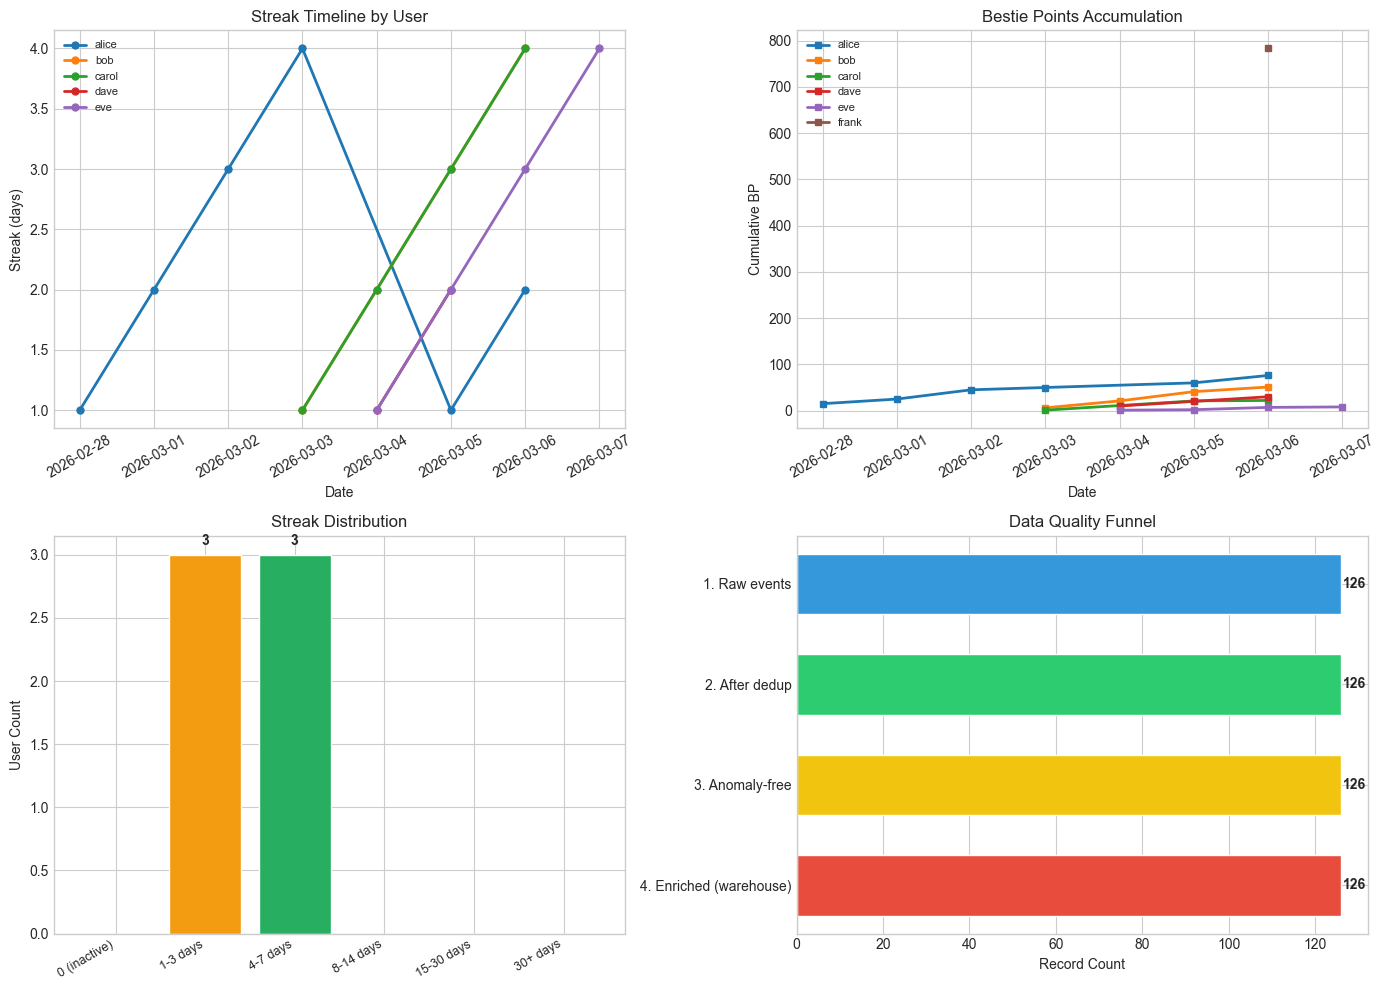

All 4 charts rendered successfully.


In [30]:
%matplotlib inline

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Chart 1: Streak Timeline (per user over time) ─────────────────────────
ax1 = axes[0, 0]
# Build streak timeline from DailyActivity
daily_sorted = daily_df.sort_values(["user_id", "activity_date"]).copy()
# Exclude Frank (too many events, clutters the chart)
daily_sorted = daily_sorted[daily_sorted["user_id"] != "usr_frank"]

for uid, group in daily_sorted.groupby("user_id"):
    dates = pd.to_datetime(group["activity_date"])
    # Compute running streak for timeline
    streak_vals = []
    current = 0
    prev_date = None
    for d in dates:
        if prev_date is not None and (d - prev_date).days == 1:
            current += 1
        else:
            current = 1
        streak_vals.append(current)
        prev_date = d
    ax1.plot(dates, streak_vals, marker="o", label=uid.replace("usr_", ""), linewidth=2, markersize=5)

ax1.set_title("Streak Timeline by User")
ax1.set_xlabel("Date")
ax1.set_ylabel("Streak (days)")
ax1.legend(loc="upper left", fontsize=8)
ax1.tick_params(axis="x", rotation=30)

# ── Chart 2: BP Accumulation (cumulative points) ──────────────────────────
ax2 = axes[0, 1]
bp_timeline = enriched_df.copy()
bp_timeline["event_date_dt"] = pd.to_datetime(bp_timeline["event_date"])
for uid, group in bp_timeline.groupby("user_id"):
    daily_pts = group.groupby("event_date_dt")["points_awarded"].sum().sort_index().cumsum()
    ax2.plot(daily_pts.index, daily_pts.values, marker="s", label=uid.replace("usr_", ""),
             linewidth=2, markersize=4)

ax2.set_title("Bestie Points Accumulation")
ax2.set_xlabel("Date")
ax2.set_ylabel("Cumulative BP")
ax2.legend(loc="upper left", fontsize=8)
ax2.tick_params(axis="x", rotation=30)

# ── Chart 3: Streak Distribution (from analytical view) ───────────────────
ax3 = axes[1, 0]
bucket_order = ["0 (inactive)", "1-3 days", "4-7 days", "8-14 days", "15-30 days", "30+ days"]
dist_data = streak_dist.set_index("streak_bucket").reindex(bucket_order).fillna(0)
colors = ["#e74c3c", "#f39c12", "#27ae60", "#2980b9", "#8e44ad", "#2c3e50"]
bars = ax3.bar(range(len(dist_data)), dist_data["user_count"].values,
               color=colors[:len(dist_data)], edgecolor="white")
ax3.set_xticks(range(len(dist_data)))
ax3.set_xticklabels(dist_data.index, rotation=30, ha="right", fontsize=9)
ax3.set_title("Streak Distribution")
ax3.set_ylabel("User Count")
# Add value labels on bars
for bar_item, val in zip(bars, dist_data["user_count"].values):
    if val > 0:
        ax3.text(bar_item.get_x() + bar_item.get_width() / 2, bar_item.get_height() + 0.05,
                 str(int(val)), ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── Chart 4: Dedup Funnel ─────────────────────────────────────────────────
ax4 = axes[1, 1]
funnel_labels = list(funnel.keys())
funnel_values = list(funnel.values())
bar_colors = ["#3498db", "#2ecc71", "#f1c40f", "#e74c3c"]
y_pos = range(len(funnel_labels))
ax4.barh(y_pos, funnel_values, color=bar_colors[:len(funnel_labels)], edgecolor="white", height=0.6)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(funnel_labels)
ax4.invert_yaxis()
ax4.set_title("Data Quality Funnel")
ax4.set_xlabel("Record Count")
# Add count labels
for i, v in enumerate(funnel_values):
    ax4.text(v + 0.5, i, str(v), va="center", fontweight="bold")

plt.tight_layout()
plt.savefig("pipeline_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("All 4 charts rendered successfully.")

---
## Section 10: Bug Fix Summary & Discussion Points

### Bugs Found & Fixed

| # | File | Problem | Fix | Severity |
|---|---|---|---|---|
| 1 | `event_ingestion.py` | `attribute_not_exists` on new item always passes — **dedup broken** | Query `IdempotencyIndex` GSI before write (Layer 2) | Critical |
| 2 | `table_definitions.py` | No `StreamSpecification` on DailyActivity | Add `StreamEnabled: True, StreamViewType: NEW_IMAGE` | High |
| 3 | `streak_processor.py` | `get_previous_date` ignores `timezone` param — **DST-unsafe** | Use timezone-aware datetime with noon anchor | Medium |
| 4 | `event_ingestion.py` | Rate limiting / anomaly detection not integrated | Add `check_rate_limit()` + `detect_timezone_abuse()` + maintain `recent_tz_changes` | Medium |
| 5 | `data-modeling.md` | Diagram shows `DAX / ElastiCache` but code uses Redis | Updated to `ElastiCache Redis` consistently | Low |
| 6 | `event_ingestion.py` | 3 sequential writes are not atomic | Documented trade-off; nightly reconciliation job detects/repairs | Design |

### Interview Talking Points

- **DynamoDB vs Aurora**: HTTP-based (no connection pooling bottleneck), auto-scaling, conditional writes for optimistic locking, Streams for CDC. Aurora works at moderate scale but requires connection management and read replicas.
- **Write-through cache**: Streak data must be immediately consistent — user should see the updated streak instantly. Write-behind would introduce a staleness window.
- **Optimistic locking**: `version` attribute prevents concurrent Lambda invocations from overwriting each other. Retry on `ConditionalCheckFailedException` re-reads fresh state.
- **Timezone as first-class concern**: All dates derived server-side from `client_timestamp` + `timezone`. Never trust client date calculation. `activity_date` is always in the user's local timezone.
- **Multi-layer dedup**: Layer 1 (client key) → Layer 2 (GSI lookup) → Layer 3 (conditional write). Each layer catches different failure modes.
- **Atomicity trade-off**: DynamoDB doesn't support efficient cross-table transactions at scale. Accept eventual consistency with nightly reconciliation rather than pay the latency/cost of `TransactWriteItems`.

---
## Section 11: Cleanup & Teardown

Stops all mocks and closes connections to leave no side effects:

- **`mock.stop()`** — releases moto's boto3 interception so subsequent boto3 calls hit real AWS (if any)
- **SQLite connection closed** — flushes any pending writes
- **Environment variables cleaned** — removes dummy AWS credentials set in Section 1

> **Note:** fakeredis is garbage-collected automatically — no explicit cleanup needed.

In [31]:
# ── Close SQLite connection ───────────────────────────────────────────────
conn.close()
print("SQLite connection closed.")

# ── Stop moto mock — release all in-memory DynamoDB state ─────────────────
mock.stop()
print("Moto mock stopped.")

# ── Clear environment variables ───────────────────────────────────────────
for key in ["AWS_ACCESS_KEY_ID", "AWS_SECRET_ACCESS_KEY", "AWS_DEFAULT_REGION"]:
    os.environ.pop(key, None)

print("\nAll mocks stopped. Notebook complete.")
print("="*60)
print("SUMMARY")
print("="*60)
print(f"  Events generated:   {len(events)}")
print(f"  Events processed:   {results['processed']}")
print(f"  Duplicates caught:  {results['duplicate']}")
print(f"  Rate-limited:       {results['rate_limited']}")
print(f"  Validation errors:  {results['validation_error']}")
print(f"  Warehouse rows:     {enriched_count}")
print(f"  Analytical views:   3 (weekly stats, streak dist, event perf)")
print(f"  Charts rendered:    4")
print(f"  Assertions passed:  All")

SQLite connection closed.
Moto mock stopped.

All mocks stopped. Notebook complete.
SUMMARY
  Events generated:   148
  Events processed:   126
  Duplicates caught:  12
  Rate-limited:       5
  Validation errors:  5
  Warehouse rows:     126
  Analytical views:   3 (weekly stats, streak dist, event perf)
  Charts rendered:    4
  Assertions passed:  All
